# ARIMA Model Testing

In [3]:
import itertools
import logging
import os
import time
import warnings
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from joblib import Parallel, delayed, parallel_config
from scipy import stats
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

sns.set_palette('colorblind')
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='mlflow')
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting ARIMA'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### Target Transformations

Three target transformations are compared in the grid. The model is always evaluated on
the **original scale**: forecasts are inverse-transformed back to arrival counts before
computing the test metrics.

| Option | Transform | Inverse |
|---|---|---|
| `none` | identity (raw arrival counts) | identity |
| `log` | `log(y)` | `exp(ŷ)` |
| `auto_stationary` | `AutoStationaryTransformer` (AutoML) | exact `inverse_transform` of the fitted pipeline |

**`auto_stationary`** comes from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

During `fit` (`src/transforms/target_transformations.py`) it runs the tests explored in
notebook 3 and adds a step only when the test asks for it:

1. `check_trend` (Mann-Kendall). If a trend is found → `DetrendingTransformer` (linear).
2. `check_seasonality` at m = 12. If seasonal → `DeseasonalizingTransformer` (period averages).
3. `check_heteroscedastisticity` (White). If heteroscedastic → `AddMTransformer` when needed,
   then `BoxCoxTransformer` with Guerrero λ.

The transformer is fitted separately on each training window.

The repository is expected as a sibling folder of this project (override with the
`MTSF_REPO_PATH` environment variable).

In [4]:
import sys

# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
    BoxCoxTransformer,
)

SEASONAL_PERIOD = 12
FREQ = 'ME'


def fit_auto_stationary(train_series):
    """Fit a fresh AutoStationaryTransformer (Mann-Kendall trend, Guerrero Box-Cox)."""
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    transformer = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return transformer.fit(train_series, freq=FREQ)


def describe_pipeline(transformer):
    steps = [
        type(tr).__name__.replace('Transformer', '') for tr in transformer._pipeline
    ]
    return ' → '.join(steps) if steps else '(none)'


class IdentityTarget:
    """No target transformation."""

    @staticmethod
    def transform(y):
        return y

    @staticmethod
    def inverse_transform(y):
        return y


class LogTarget:
    """Natural log of the arrival counts; inverse is exp."""

    @staticmethod
    def transform(y):
        return np.log(y)

    @staticmethod
    def inverse_transform(y):
        return np.exp(y)


def fit_target_transform(name, train_series):
    """Return a fitted transformer exposing `transform` / `inverse_transform`."""
    if name == 'none':
        return IdentityTarget()
    if name == 'log':
        return LogTarget()
    if name == 'auto_stationary':
        return fit_auto_stationary(train_series)
    raise ValueError(f'unknown target transform: {name}')

## Data Preparation

Several training data selections are evaluated in the grid search:

- **`last_{14,12,10,8,6,4}y_covid_exog`** — last N years with a 0/1 COVID regressor (`is_covid`) to absorb the structural break
- **`last_{14,12,10,8,6,4}y_covid_recovery_exog`** — same windows but with **two** regressors: `is_covid` (Jan 2020–Dec 2021) **and** `is_covid_recovery` (Jan 2022–Jun 2022), the 12-month rebound period immediately after the pandemic
- **`post_covid`** — only post-COVID data (2022 onwards); no exog needed, cleaner signal
- **`post_covid_recovery_exog`** — same post-COVID window with `is_covid_recovery` (Jan 2022–Jun 2022) to explicitly model the rebound year within that short series

Every selection is crossed with the three target transformations (`none`, `log`, `auto_stationary`). The `AutoStationaryTransformer` is fitted on each training window only (the raw arrival counts).

Evaluation metrics are computed on **test.parquet** (the last 12 months of the data, split in notebook 2) for all models, after inverse-transforming the forecasts back to arrival counts. The training windows are counted back from the last training month, so every date in this notebook follows the data.

In [5]:
train_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))
train_monthly = train_df.set_index('date')[['arrival_count']].resample('ME').sum()
train_monthly['is_covid'] = (
    (train_monthly.index >= COVID_START) & (train_monthly.index <= COVID_END)
).astype(float)
train_monthly['is_covid_recovery'] = (
    (train_monthly.index >= POST_COVID_START)
    & (train_monthly.index <= COVID_RECOVERY_END)
).astype(float)

test_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'test.parquet'))
test_monthly = test_df.set_index('date')[['arrival_count']].resample('ME').sum()
test_monthly['is_covid'] = 0.0
test_monthly['is_covid_recovery'] = 0.0

window_years = [14, 12, 10, 8, 6, 4]
train_windows = {}
for years in window_years:
    start = train_monthly.index[-1] - pd.DateOffset(years=years)
    train_windows[years] = train_monthly[train_monthly.index >= start].copy()

train_post_covid = train_monthly[train_monthly.index >= POST_COVID_START].copy()

print(
    f'Full train  : {train_monthly.index[0].strftime("%b %Y")} → {train_monthly.index[-1].strftime("%b %Y")} ({len(train_monthly)} obs)'
)
for years in window_years:
    tw = train_windows[years]
    print(
        f'Last {years:>2}y    : {tw.index[0].strftime("%b %Y")} → {tw.index[-1].strftime("%b %Y")} ({len(tw)} obs, COVID obs: {int(tw["is_covid"].sum())}, recovery obs: {int(tw["is_covid_recovery"].sum())})'
    )
print(
    f'Post-COVID  : {train_post_covid.index[0].strftime("%b %Y")} → {train_post_covid.index[-1].strftime("%b %Y")} ({len(train_post_covid)} obs)'
)
print(
    f'Test        : {test_monthly.index[0].strftime("%b %Y")} → {test_monthly.index[-1].strftime("%b %Y")} ({len(test_monthly)} obs)'
)

Full train  : Jan 1989 → Aug 2025 (440 obs)
Last 14y    : Aug 2011 → Aug 2025 (169 obs, COVID obs: 24, recovery obs: 6)
Last 12y    : Aug 2013 → Aug 2025 (145 obs, COVID obs: 24, recovery obs: 6)
Last 10y    : Aug 2015 → Aug 2025 (121 obs, COVID obs: 24, recovery obs: 6)
Last  8y    : Aug 2017 → Aug 2025 (97 obs, COVID obs: 24, recovery obs: 6)
Last  6y    : Aug 2019 → Aug 2025 (73 obs, COVID obs: 24, recovery obs: 6)
Last  4y    : Aug 2021 → Aug 2025 (49 obs, COVID obs: 5, recovery obs: 6)
Post-COVID  : Jan 2022 → Aug 2025 (44 obs)
Test        : Sep 2025 → Aug 2026 (12 obs)


## Model Selection Grid

Grid dimensions:
- **SARIMAX orders**: `p, q ∈ {0,1,2}`, `d ∈ {0,1}`, `P, Q ∈ {0,1}`, `D ∈ {0,1}`, `s = 12`
  → 144 configs. The differencing orders are **searched**, not fixed, and independently of
  the target transformation. This way, the grid shows directly whether a transformation
  (e.g. the AutoML detrend/deseasonalize) replaces differencing or still needs it.
- **Target transformation**: `none`, `log`, `auto_stationary` → 3 options
- **Training data selection**: `last_14y/12y/10y/8y/6y/4y_covid_exog`, `last_14y/12y/10y/8y/6y/4y_covid_recovery_exog`, `post_covid`, or `post_covid_recovery_exog` → 14 options
- **Total runs**: 6,048 — one MLflow run per (order, target transformation, data selection)

**Execution.** The grid runs in two phases:

1. **Fit in parallel.** Each task (data selection, transformation, order) is fitted and scored in a separate process with `joblib` (`N_JOBS` workers, one BLAS thread each to avoid oversubscription). Workers never touch MLflow; every task catches its own errors and returns them as a failed result.
2. **Log from the main process.** Every result becomes one MLflow run (params + metrics, including `fit_seconds`, in a single `log_batch` call). Runs are logged from `N_LOG_THREADS` threads, because the cost is the HTTP round-trips to the server, not CPU. Failed fits are logged with status `FAILED` and an `error` param.

> AIC/BIC are computed on the transformed scale and depend on the differencing, so they
> are only comparable *within* the same data selection, transformation and `(d, D)`.
> Models are ranked across the grid by test RMSE on the original scale.

In [6]:
s = 12

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)

sarimax_grid = list(
    itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range)
)

TARGET_TRANSFORMS = ['none', 'log', 'auto_stationary']

# ── training data selections (raw target + exogenous regressors) ─────────────
data_selections = {}

for years in window_years:
    tw = train_windows[years]
    # COVID indicator only
    data_selections[f'last_{years}y_covid_exog'] = {
        'raw_series': tw['arrival_count'],
        'exog_train': tw[['is_covid']],
        'exog_test': test_monthly[['is_covid']],
    }
    # COVID indicator + recovery indicator (Jan–Jun 2022)
    data_selections[f'last_{years}y_covid_recovery_exog'] = {
        'raw_series': tw['arrival_count'],
        'exog_train': tw[['is_covid', 'is_covid_recovery']],
        'exog_test': test_monthly[['is_covid', 'is_covid_recovery']],
    }

data_selections['post_covid'] = {
    'raw_series': train_post_covid['arrival_count'],
    'exog_train': None,
    'exog_test': None,
}

# Post-COVID window with recovery flag to model the Jan–Jun 2022 rebound explicitly
data_selections['post_covid_recovery_exog'] = {
    'raw_series': train_post_covid['arrival_count'],
    'exog_train': train_post_covid[['is_covid_recovery']],
    'exog_test': test_monthly[['is_covid_recovery']],
}


# ── (data selection × target transformation) configs ─────────────────────────
def make_config(selection, transform_name):
    """Fit the target transformation on the training window and store the pieces."""
    transformer = fit_target_transform(transform_name, selection['raw_series'])
    is_auto = transform_name == 'auto_stationary'
    box_cox = (
        [tr for tr in transformer._pipeline if isinstance(tr, BoxCoxTransformer)]
        if is_auto
        else []
    )
    return {
        **selection,
        'target_transform': transform_name,
        'series': transformer.transform(selection['raw_series']),
        'transformer': transformer,
        'pipeline': describe_pipeline(transformer) if is_auto else transform_name,
        'boxcox_lambda': box_cox[0].boxcox_lambda if box_cox else None,
    }


model_configs = {
    (data_key, transform_name): make_config(selection, transform_name)
    for data_key, selection in data_selections.items()
    for transform_name in TARGET_TRANSFORMS
}

# ── what the AutoML pipeline chose for each training window ─────────────────
transform_summary = pd.DataFrame([
    {
        'data_selection': data_key,
        'n_train': len(cfg['raw_series']),
        'pipeline': cfg['pipeline'],
        'trend (MK p)': round(cfg['transformer']._trend_check['p_value'], 4),
        'seasonal': cfg['transformer']._seasonality_check['seasonal'],
        'hetero (White p)': round(cfg['transformer']._hetero_check['lm_p_value'], 4),
        'boxcox_λ': None
        if cfg['boxcox_lambda'] is None
        else round(cfg['boxcox_lambda'], 3),
    }
    for (data_key, transform_name), cfg in model_configs.items()
    if transform_name == 'auto_stationary'
]).set_index('data_selection')

print(f'SARIMAX configs       : {len(sarimax_grid)}')
print(f'Target transformations: {len(TARGET_TRANSFORMS)}')
print(f'Data selections       : {len(data_selections)}')
print(f'Total runs            : {len(sarimax_grid) * len(model_configs)}')
transform_summary

SARIMAX configs       : 144
Target transformations: 3
Data selections       : 14
Total runs            : 6048


,n_train,pipeline,trend (MK p),seasonal,hetero (White p),boxcox_λ
data_selection,,,,,,
last_14y_covid_exog,169,Deseasonalizing → AddM → BoxCox,0.2155,True,0.0029,1.124
last_14y_covid_recovery_exog,169,Deseasonalizing → AddM → BoxCox,0.2155,True,0.0029,1.124
last_12y_covid_exog,145,Deseasonalizing → AddM → BoxCox,0.2838,True,0.0442,1.153
last_12y_covid_recovery_exog,145,Deseasonalizing → AddM → BoxCox,0.2838,True,0.0442,1.153
last_10y_covid_exog,121,Deseasonalizing → AddM → BoxCox,0.7657,True,0.0247,1.561
last_10y_covid_recovery_exog,121,Deseasonalizing → AddM → BoxCox,0.7657,True,0.0247,1.561
last_8y_covid_exog,97,Deseasonalizing,0.0859,True,0.3878,NaN
last_8y_covid_recovery_exog,97,Deseasonalizing,0.0859,True,0.3878,NaN
last_6y_covid_exog,73,Detrending → Deseasonalizing → AddM → BoxCox,0.0000,True,0.0001,0.782


## MLflow Setup

`mlflow.statsmodels.autolog` is **disabled**:

- It saved a pickled statsmodels model (plus a full `uv` environment export) for every
  run, which took about 90% of each run's time. A SARIMAX fit takes 0.02–0.5 s, while a run
  with autolog took about 5 s.
- The grid fits run in parallel worker processes, where autolog would not work.
- The `AutoStationaryTransformer` tests (ADF, White/OLS) call statsmodels `fit` internally,
  and autolog would log each of them as a separate run.

Each grid run logs its parameters and metrics explicitly. Only the **best** model is
saved as a model artifact, at the end of the notebook (*Save the Best Model to MLflow*).

The tracking server runs in Docker (`docker compose up -d mlflow`, or `task mlflow`) and is
reached through `MLFLOW_TRACKING_URI=http://localhost:5000` in `.env`.

In [7]:
mlflow.statsmodels.autolog(disable=True)

print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment  : {experiment.name} (id {experiment.experiment_id})')

Tracking URI: http://localhost:5000
Experiment  : Brazil Tourism Forecasting ARIMA (id 2)


In [8]:
test_actual = test_monthly['arrival_count'].values
n_test = len(test_monthly)

# physical cores: SARIMAX fits are CPU-bound, hyper-threads add little
N_JOBS = max(1, (os.cpu_count() or 2) // 2)


def forecast_arrivals(fit, cfg, steps=n_test, index=test_monthly.index):
    """Forecast on the transformed scale and inverse-transform to arrival counts."""
    transformed = np.asarray(fit.forecast(steps=steps, exog=cfg['exog_test']))
    forecast = cfg['transformer'].inverse_transform(pd.Series(transformed, index=index))
    return forecast.to_numpy()


def fit_one(data_key, transform_name, cfg, order_spec):
    """Fit and score one grid point. Runs in a worker process — no MLflow calls."""
    p, d, q, P, D, Q = order_spec
    order = (p, d, q)
    seasonal_order = (P, D, Q, s)
    result = {
        'data_selection': data_key,
        'target_transform': transform_name,
        'run_name': (
            f'SARIMAX({p},{d},{q})({P},{D},{Q})[{s}] ({data_key} | {transform_name})'
        ),
        'order': order,
        'seasonal_order': seasonal_order,
        'd': d,
        'D': D,
    }
    start = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit = SARIMAX(
                cfg['series'],
                exog=cfg['exog_train'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)

            forecast = forecast_arrivals(fit, cfg)
        if not np.all(np.isfinite(forecast)):
            raise ValueError('non-finite forecast after inverse transform')

        errors = test_actual - forecast
        result.update({
            'aicc': fit.aicc,
            'aic': fit.aic,
            'bic': fit.bic,
            'rmse': float(np.sqrt(np.mean(errors**2))),
            'mae': float(np.mean(np.abs(errors))),
            'mape': float(np.mean(np.abs(errors / test_actual)) * 100),
            'r2': float(r2_score(test_actual, forecast)),
            'converged': True,
            'error': None,
        })
    except Exception as exc:
        result.update({
            'aic': np.inf,
            'bic': np.inf,
            'rmse': np.inf,
            'mae': np.inf,
            'mape': np.inf,
            'r2': -np.inf,
            'converged': False,
            'error': str(exc)[:250],
        })
    result['fit_seconds'] = time.perf_counter() - start
    return result


# ── phase 1: fit every grid point in parallel ────────────────────────────────
tasks = [
    (data_key, transform_name, cfg, order_spec)
    for (data_key, transform_name), cfg in model_configs.items()
    for order_spec in sarimax_grid
]
print(f'Fitting {len(tasks)} models on {N_JOBS} workers...')

grid_start = time.perf_counter()
with parallel_config(backend='loky', inner_max_num_threads=1):
    results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(fit_one)(*task) for task in tasks
    )
print(f'Fitting done in {time.perf_counter() - grid_start:,.0f}s')


# ── phase 2: log every result to MLflow from the main process ────────────────
def log_result(client, result):
    cfg = model_configs[(result['data_selection'], result['target_transform'])]
    p, d, q = result['order']
    P, D, Q, _ = result['seasonal_order']
    exog_label = (
        '+'.join(cfg['exog_train'].columns) if cfg['exog_train'] is not None else 'none'
    )
    params = {
        'p': p,
        'd': d,
        'q': q,
        'P': P,
        'D': D,
        'Q': Q,
        's': s,
        'transform': result['target_transform'],
        'ast_pipeline': cfg['pipeline'],
        'boxcox_lambda': cfg['boxcox_lambda'] or 'none',
        'data_selection': result['data_selection'],
        'exog': exog_label,
        'n_train': len(cfg['series']),
        'n_test': n_test,
    }
    if result['error']:
        params['error'] = result['error']

    metric_keys = ['aicc', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2', 'fit_seconds']
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key, float(result[key]), timestamp, 0)
        for key in metric_keys
        if key in result and np.isfinite(result[key])
    ]

    run = client.create_run(experiment.experiment_id, run_name=result['run_name'])
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(
        run.info.run_id, status='FINISHED' if result['converged'] else 'FAILED'
    )


# each run is 3 HTTP calls; threads overlap the request latency (~3x faster)
N_LOG_THREADS = 8

client = mlflow.MlflowClient()
log_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as executor:
    list(
        tqdm(
            executor.map(lambda result: log_result(client, result), results),
            total=len(results),
            desc='Logging to MLflow',
        )
    )
print(f'Logging done in {time.perf_counter() - log_start:,.0f}s')

results_df = (
    pd.DataFrame(results).query('converged').sort_values('rmse').reset_index(drop=True)
)

print(f'Converged: {len(results_df)} / {len(tasks)}')
results_df.head(10)

Fitting 6048 models on 8 workers...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    2.9s
[Parallel(n_jobs=8)]: Done 228 tasks      | elapsed:    8.6s
[Parallel(n_jobs=8)]: Done 400 tasks      | elapsed:   16.7s
[Parallel(n_jobs=8)]: Done 562 tasks      | elapsed:   22.0s
[Parallel(n_jobs=8)]: Done 760 tasks      | elapsed:   30.9s
[Parallel(n_jobs=8)]: Done 994 tasks      | elapsed:   38.0s
[Parallel(n_jobs=8)]: Done 1328 tasks      | elapsed:   47.8s
[Parallel(n_jobs=8)]: Done 1940 tasks      | elapsed:  1.1min
[Parallel(n_jobs=8)]: Done 2624 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done 3380 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 4208 tasks      | elapsed:  1.9min
[Parallel(n_jobs=8)]: Done 5108 tasks      | elapsed:  2.2min
[Parallel(n_jobs=8)]: Done 6048 out of 6048 | elapsed:  2.5min finished


Fitting done in 148s


Logging to MLflow: 100%|██████████| 6048/6048 [18:20<00:00,  5.50it/s]

Logging done in 1,101s
Converged: 5991 / 6048


,data_selection,target_transform,run_name,order,seasonal_order,d,D,aicc,aic,bic,rmse,mae,mape,r2,converged,error,fit_seconds
0,last_14y_covid_recovery_exog,log,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_reco...","(2, 1, 1)","(1, 1, 0, 12)",1,1,309.836678,309.000857,329.691647,32400.760130,25949.970046,3.442540,0.988777,True,None,1.219993
1,last_10y_covid_recovery_exog,log,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_reco...","(2, 1, 1)","(1, 1, 0, 12)",1,1,242.097921,240.795595,258.598658,32448.056199,23813.182060,3.024910,0.988744,True,None,0.611641
2,last_12y_covid_exog,log,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_exog...","(1, 1, 2)","(1, 1, 0, 12)",1,1,275.814108,275.064108,291.738849,37859.256771,31148.693714,4.113335,0.984677,True,None,0.505877
3,last_8y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_exog ...","(1, 0, 0)","(1, 1, 0, 12)",0,1,201.237547,200.640532,209.747196,38883.154881,29423.569493,3.895347,0.983837,True,None,0.107228
4,last_8y_covid_recovery_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_recov...","(1, 0, 0)","(1, 1, 0, 12)",0,1,203.549601,202.640510,214.023841,38890.013951,29405.918653,3.892168,0.983831,True,None,0.164483
5,last_10y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_exog...","(1, 0, 0)","(1, 1, 0, 12)",0,1,238.467855,238.028295,248.285688,38967.886459,29626.458365,3.929313,0.983766,True,None,0.142123
6,last_10y_covid_recovery_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_reco...","(1, 0, 0)","(1, 1, 0, 12)",0,1,240.694962,240.028295,252.850036,38968.043383,29626.393696,3.929299,0.983766,True,None,0.230221
7,last_12y_covid_recovery_exog,log,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_reco...","(1, 1, 2)","(1, 1, 0, 12)",1,1,277.982579,276.973570,296.427434,39284.071524,32991.758117,4.382110,0.983502,True,None,0.731312
8,last_12y_covid_recovery_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_reco...","(1, 0, 0)","(1, 1, 0, 12)",0,1,273.800727,273.274411,287.211870,39319.001884,30092.917178,4.005434,0.983472,True,None,0.236272
9,last_12y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_exog...","(1, 0, 0)","(1, 1, 0, 12)",0,1,271.622408,271.274582,282.424549,39325.347092,30053.509553,3.998309,0.983467,True,None,0.153162


## Results

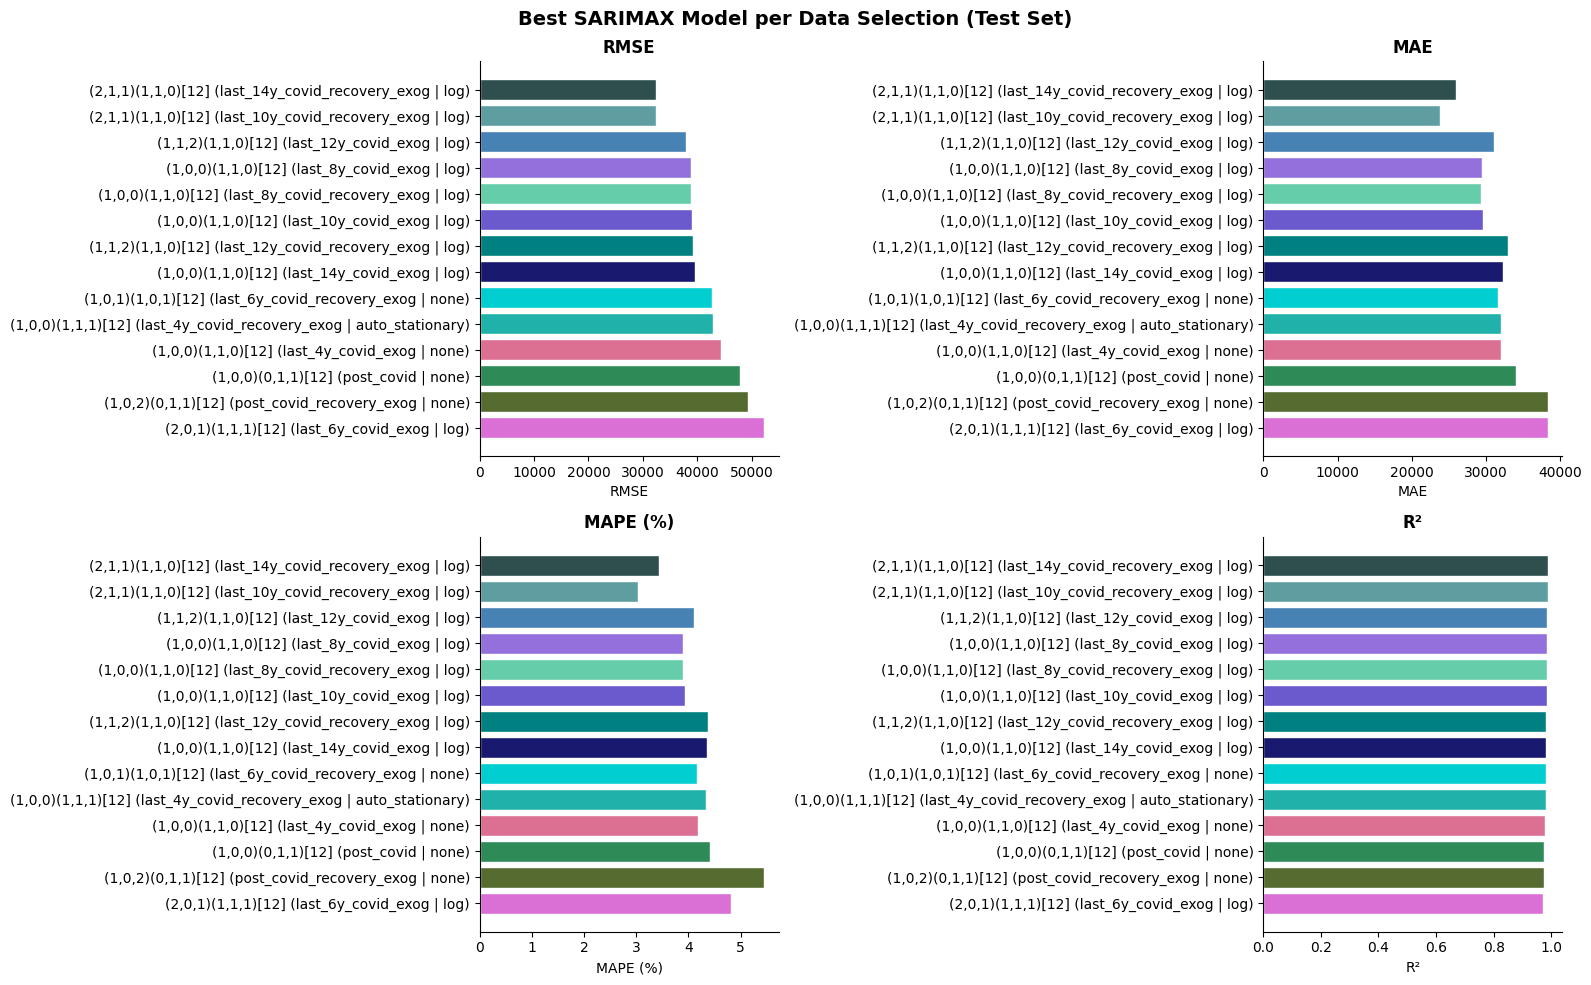

,data_selection,target_transform,run_name,rmse,mae,mape,r2
0,last_14y_covid_recovery_exog,log,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_reco...",32400.760130,25949.970046,3.442540,0.988777
1,last_10y_covid_recovery_exog,log,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_reco...",32448.056199,23813.182060,3.024910,0.988744
2,last_12y_covid_exog,log,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_exog...",37859.256771,31148.693714,4.113335,0.984677
3,last_8y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_exog ...",38883.154881,29423.569493,3.895347,0.983837
4,last_8y_covid_recovery_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_recov...",38890.013951,29405.918653,3.892168,0.983831
5,last_10y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_exog...",38967.886459,29626.458365,3.929313,0.983766
6,last_12y_covid_recovery_exog,log,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_reco...",39284.071524,32991.758117,4.382110,0.983502
7,last_14y_covid_exog,log,"SARIMAX(1,0,0)(1,1,0)[12] (last_14y_covid_exog...",39583.486308,32263.341832,4.354983,0.983249
8,last_6y_covid_recovery_exog,none,"SARIMAX(1,0,1)(1,0,1)[12] (last_6y_covid_recov...",42676.917626,31631.081203,4.158456,0.980529
9,last_4y_covid_recovery_exog,auto_stationary,"SARIMAX(1,0,0)(1,1,1)[12] (last_4y_covid_recov...",42834.101806,32026.550089,4.332684,0.980385


In [9]:
palette = {
    'last_14y_covid_exog': 'midnightblue',
    'last_12y_covid_exog': 'steelblue',
    'last_10y_covid_exog': 'slateblue',
    'last_8y_covid_exog': 'mediumpurple',
    'last_6y_covid_exog': 'orchid',
    'last_4y_covid_exog': 'palevioletred',
    'last_14y_covid_recovery_exog': 'darkslategray',
    'last_12y_covid_recovery_exog': 'teal',
    'last_10y_covid_recovery_exog': 'cadetblue',
    'last_8y_covid_recovery_exog': 'mediumaquamarine',
    'last_6y_covid_recovery_exog': 'darkturquoise',
    'last_4y_covid_recovery_exog': 'lightseagreen',
    'post_covid': 'seagreen',
    'post_covid_recovery_exog': 'darkolivegreen',
}

best_per_selection = (
    results_df
    .sort_values('rmse')
    .groupby('data_selection', sort=False)
    .first()
    .reset_index()
    .sort_values('rmse')
    .reset_index(drop=True)
)
best_per_selection['label'] = best_per_selection['run_name'].str.replace(
    'SARIMAX', '', regex=False
)
bar_colors = [palette[ds] for ds in best_per_selection['data_selection'][::-1]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Best SARIMAX Model per Data Selection (Test Set)',
    fontsize=14,
    fontweight='bold',
)

for ax, (col, title) in zip(
    axes.flat, [('rmse', 'RMSE'), ('mae', 'MAE'), ('mape', 'MAPE (%)'), ('r2', 'R²')]
):
    ax.barh(
        best_per_selection['label'][::-1],
        best_per_selection[col][::-1],
        color=bar_colors,
        edgecolor='white',
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

display(
    best_per_selection[
        [
            'data_selection',
            'target_transform',
            'run_name',
            'rmse',
            'mae',
            'mape',
            'r2',
        ]
    ]
)

### Effect of Target Transformation and Differencing

Best test RMSE for each target transformation, within each data selection and for each
`(d, D)` combination. Every cell is the best model of its group across all remaining
orders. These tables answer whether a transformation helps, and whether it replaces or
still needs differencing.

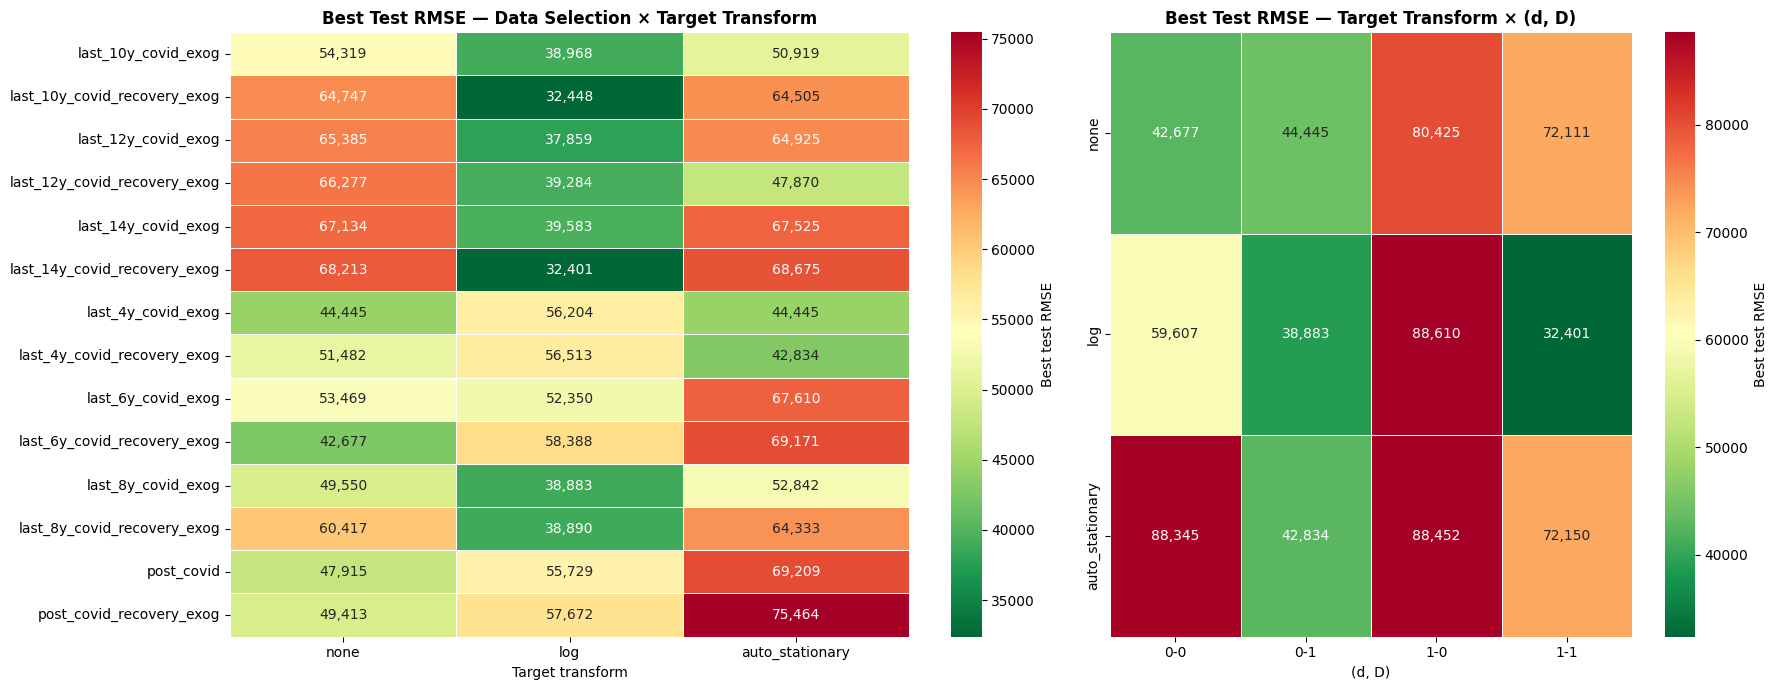

target_transform,none,log,auto_stationary,best
data_selection,,,,
last_10y_covid_exog,54319.0,38968.0,50919.0,log
last_10y_covid_recovery_exog,64747.0,32448.0,64505.0,log
last_12y_covid_exog,65385.0,37859.0,64925.0,log
last_12y_covid_recovery_exog,66277.0,39284.0,47870.0,log
last_14y_covid_exog,67134.0,39583.0,67525.0,log
last_14y_covid_recovery_exog,68213.0,32401.0,68675.0,log
last_4y_covid_exog,44445.0,56204.0,44445.0,none
last_4y_covid_recovery_exog,51482.0,56513.0,42834.0,auto_stationary
last_6y_covid_exog,53469.0,52350.0,67610.0,log


d                       0                 1         
D                       0        1        0        1
target_transform                                    
none              42677.0  44445.0  80425.0  72111.0
log               59607.0  38883.0  88610.0  32401.0
auto_stationary   88345.0  42834.0  88452.0  72150.0

In [10]:
best_by_selection_transform = results_df.pivot_table(
    index='data_selection', columns='target_transform', values='rmse', aggfunc='min'
).reindex(columns=TARGET_TRANSFORMS)
best_by_selection_transform['best'] = best_by_selection_transform.idxmin(axis=1)

best_by_transform_diff = results_df.pivot_table(
    index='target_transform', columns=['d', 'D'], values='rmse', aggfunc='min'
).reindex(TARGET_TRANSFORMS)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.3, 1]})
sns.heatmap(
    best_by_selection_transform[TARGET_TRANSFORMS],
    annot=True,
    fmt=',.0f',
    cmap='RdYlGn_r',
    linewidths=0.4,
    ax=axes[0],
    cbar_kws={'label': 'Best test RMSE'},
)
axes[0].set_title(
    'Best Test RMSE — Data Selection × Target Transform', fontweight='bold'
)
axes[0].set_xlabel('Target transform')
axes[0].set_ylabel('')

sns.heatmap(
    best_by_transform_diff,
    annot=True,
    fmt=',.0f',
    cmap='RdYlGn_r',
    linewidths=0.4,
    ax=axes[1],
    cbar_kws={'label': 'Best test RMSE'},
)
axes[1].set_title('Best Test RMSE — Target Transform × (d, D)', fontweight='bold')
axes[1].set_xlabel('(d, D)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

display(best_by_selection_transform.round(0))
display(best_by_transform_diff.round(0))

## Best Model Diagnostics

In [11]:
top10 = results_df.head(10).copy()

display(
    top10[
        [
            'data_selection',
            'run_name',
            'aicc',
            'aic',
            'bic',
            'rmse',
            'mae',
            'mape',
            'r2',
        ]
    ]
)

,data_selection,run_name,aicc,aic,bic,rmse,mae,mape,r2
0,last_14y_covid_recovery_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_reco...",309.836678,309.000857,329.691647,32400.760130,25949.970046,3.442540,0.988777
1,last_10y_covid_recovery_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_reco...",242.097921,240.795595,258.598658,32448.056199,23813.182060,3.024910,0.988744
2,last_12y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_exog...",275.814108,275.064108,291.738849,37859.256771,31148.693714,4.113335,0.984677
3,last_8y_covid_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_exog ...",201.237547,200.640532,209.747196,38883.154881,29423.569493,3.895347,0.983837
4,last_8y_covid_recovery_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_recov...",203.549601,202.640510,214.023841,38890.013951,29405.918653,3.892168,0.983831
5,last_10y_covid_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_exog...",238.467855,238.028295,248.285688,38967.886459,29626.458365,3.929313,0.983766
6,last_10y_covid_recovery_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_reco...",240.694962,240.028295,252.850036,38968.043383,29626.393696,3.929299,0.983766
7,last_12y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_reco...",277.982579,276.973570,296.427434,39284.071524,32991.758117,4.382110,0.983502
8,last_12y_covid_recovery_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_reco...",273.800727,273.274411,287.211870,39319.001884,30092.917178,4.005434,0.983472
9,last_12y_covid_exog,"SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_exog...",271.622408,271.274582,282.424549,39325.347092,30053.509553,3.998309,0.983467


In [12]:
def fit_model(row, configs):
    cfg = configs[(row['data_selection'], row['target_transform'])]
    return SARIMAX(
        cfg['series'],
        exog=cfg['exog_train'],
        order=row['order'],
        seasonal_order=row['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


top10_fits = [fit_model(row, model_configs) for _, row in top10.iterrows()]

for i, (_, row) in enumerate(top10.iterrows()):
    print(f'#{i + 1:>2}  [{row["data_selection"]}]  {row["run_name"]}')

# 1  [last_14y_covid_recovery_exog]  SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_recovery_exog | log)
# 2  [last_10y_covid_recovery_exog]  SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_recovery_exog | log)
# 3  [last_12y_covid_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_exog | log)
# 4  [last_8y_covid_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_exog | log)
# 5  [last_8y_covid_recovery_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_8y_covid_recovery_exog | log)
# 6  [last_10y_covid_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_exog | log)
# 7  [last_10y_covid_recovery_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_10y_covid_recovery_exog | log)
# 8  [last_12y_covid_recovery_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_recovery_exog | log)
# 9  [last_12y_covid_recovery_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_recovery_exog | log)
#10  [last_12y_covid_exog]  SARIMAX(1,0,0)(1,1,0)[12] (last_12y_covid_exog | log)


### Residual Diagnostics

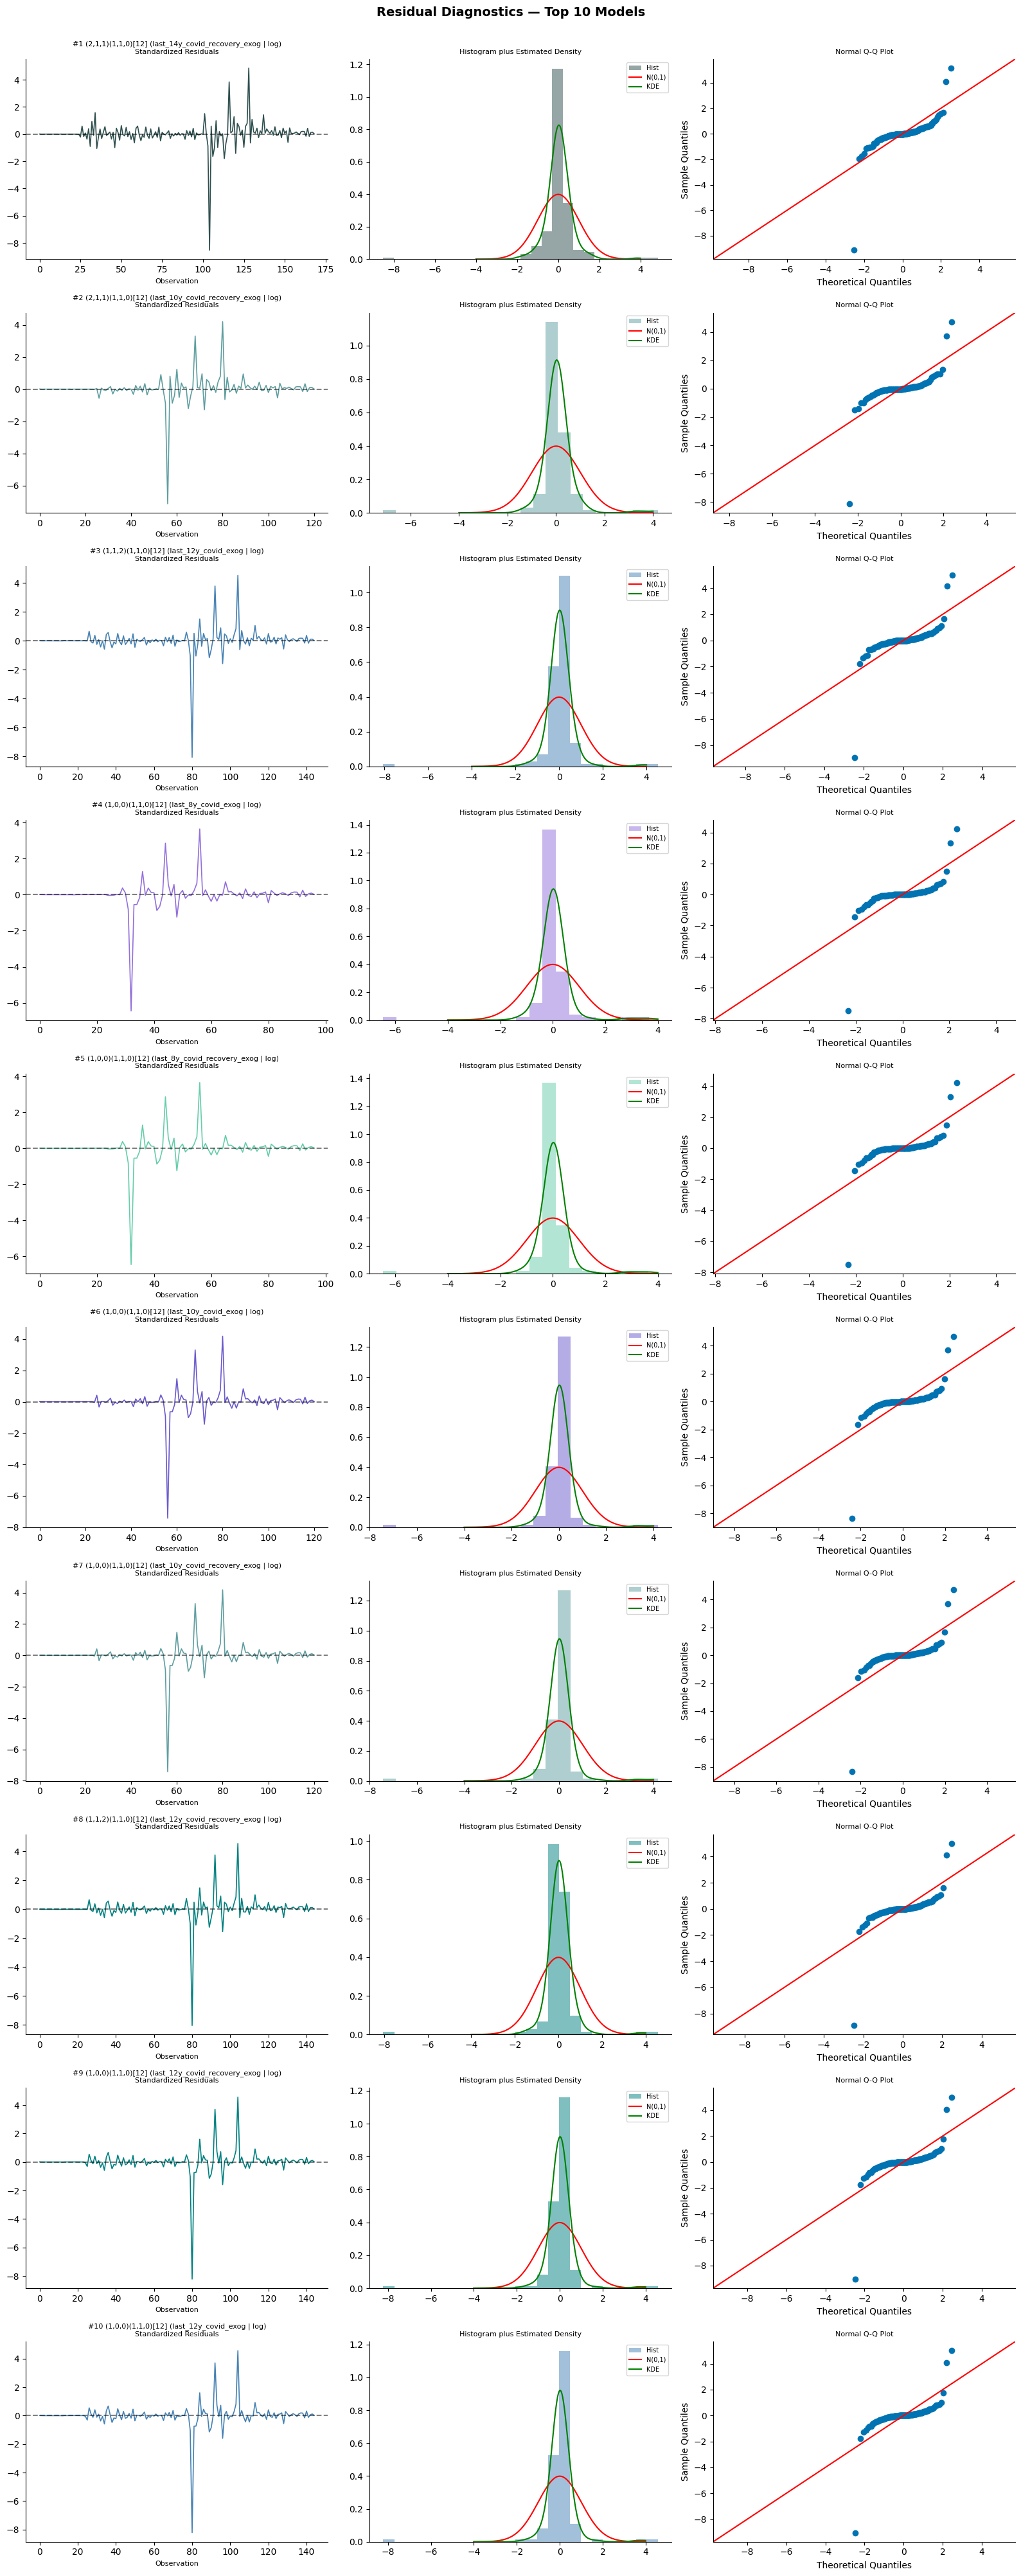

In [13]:
fig, axes = plt.subplots(10, 3, figsize=(16, 40))
fig.suptitle(
    'Residual Diagnostics — Top 10 Models', fontsize=14, fontweight='bold', y=1.001
)

x_qq = np.linspace(-4, 4, 200)

for i, ((_, row), fit) in enumerate(zip(top10.iterrows(), top10_fits)):
    std_resid = fit.filter_results.standardized_forecasts_error[0]
    std_resid = std_resid[~np.isnan(std_resid)]

    row_label = f'#{i + 1} {row["run_name"].replace("SARIMAX", "")}'

    # Standardized residuals over time
    axes[i, 0].plot(std_resid, linewidth=1.2, color=palette[row['data_selection']])
    axes[i, 0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[i, 0].set_title(f'{row_label}\nStandardized Residuals', fontsize=8)
    axes[i, 0].set_xlabel('Observation', fontsize=8)
    sns.despine(ax=axes[i, 0])

    # Histogram + KDE + N(0,1)
    axes[i, 1].hist(
        std_resid,
        bins='auto',
        density=True,
        alpha=0.5,
        color=palette[row['data_selection']],
        label='Hist',
    )
    axes[i, 1].plot(x_qq, stats.norm.pdf(x_qq, 0, 1), 'r-', label='N(0,1)')
    kde = stats.gaussian_kde(std_resid)
    axes[i, 1].plot(x_qq, kde(x_qq), 'g-', label='KDE')
    axes[i, 1].set_title('Histogram plus Estimated Density', fontsize=8)
    axes[i, 1].legend(fontsize=7)
    sns.despine(ax=axes[i, 1])

    # Normal Q-Q plot
    sm.qqplot(std_resid, line='45', fit=True, ax=axes[i, 2])
    axes[i, 2].set_title('Normal Q-Q Plot', fontsize=8)
    sns.despine(ax=axes[i, 2])

plt.tight_layout()
plt.show()

### Final Result

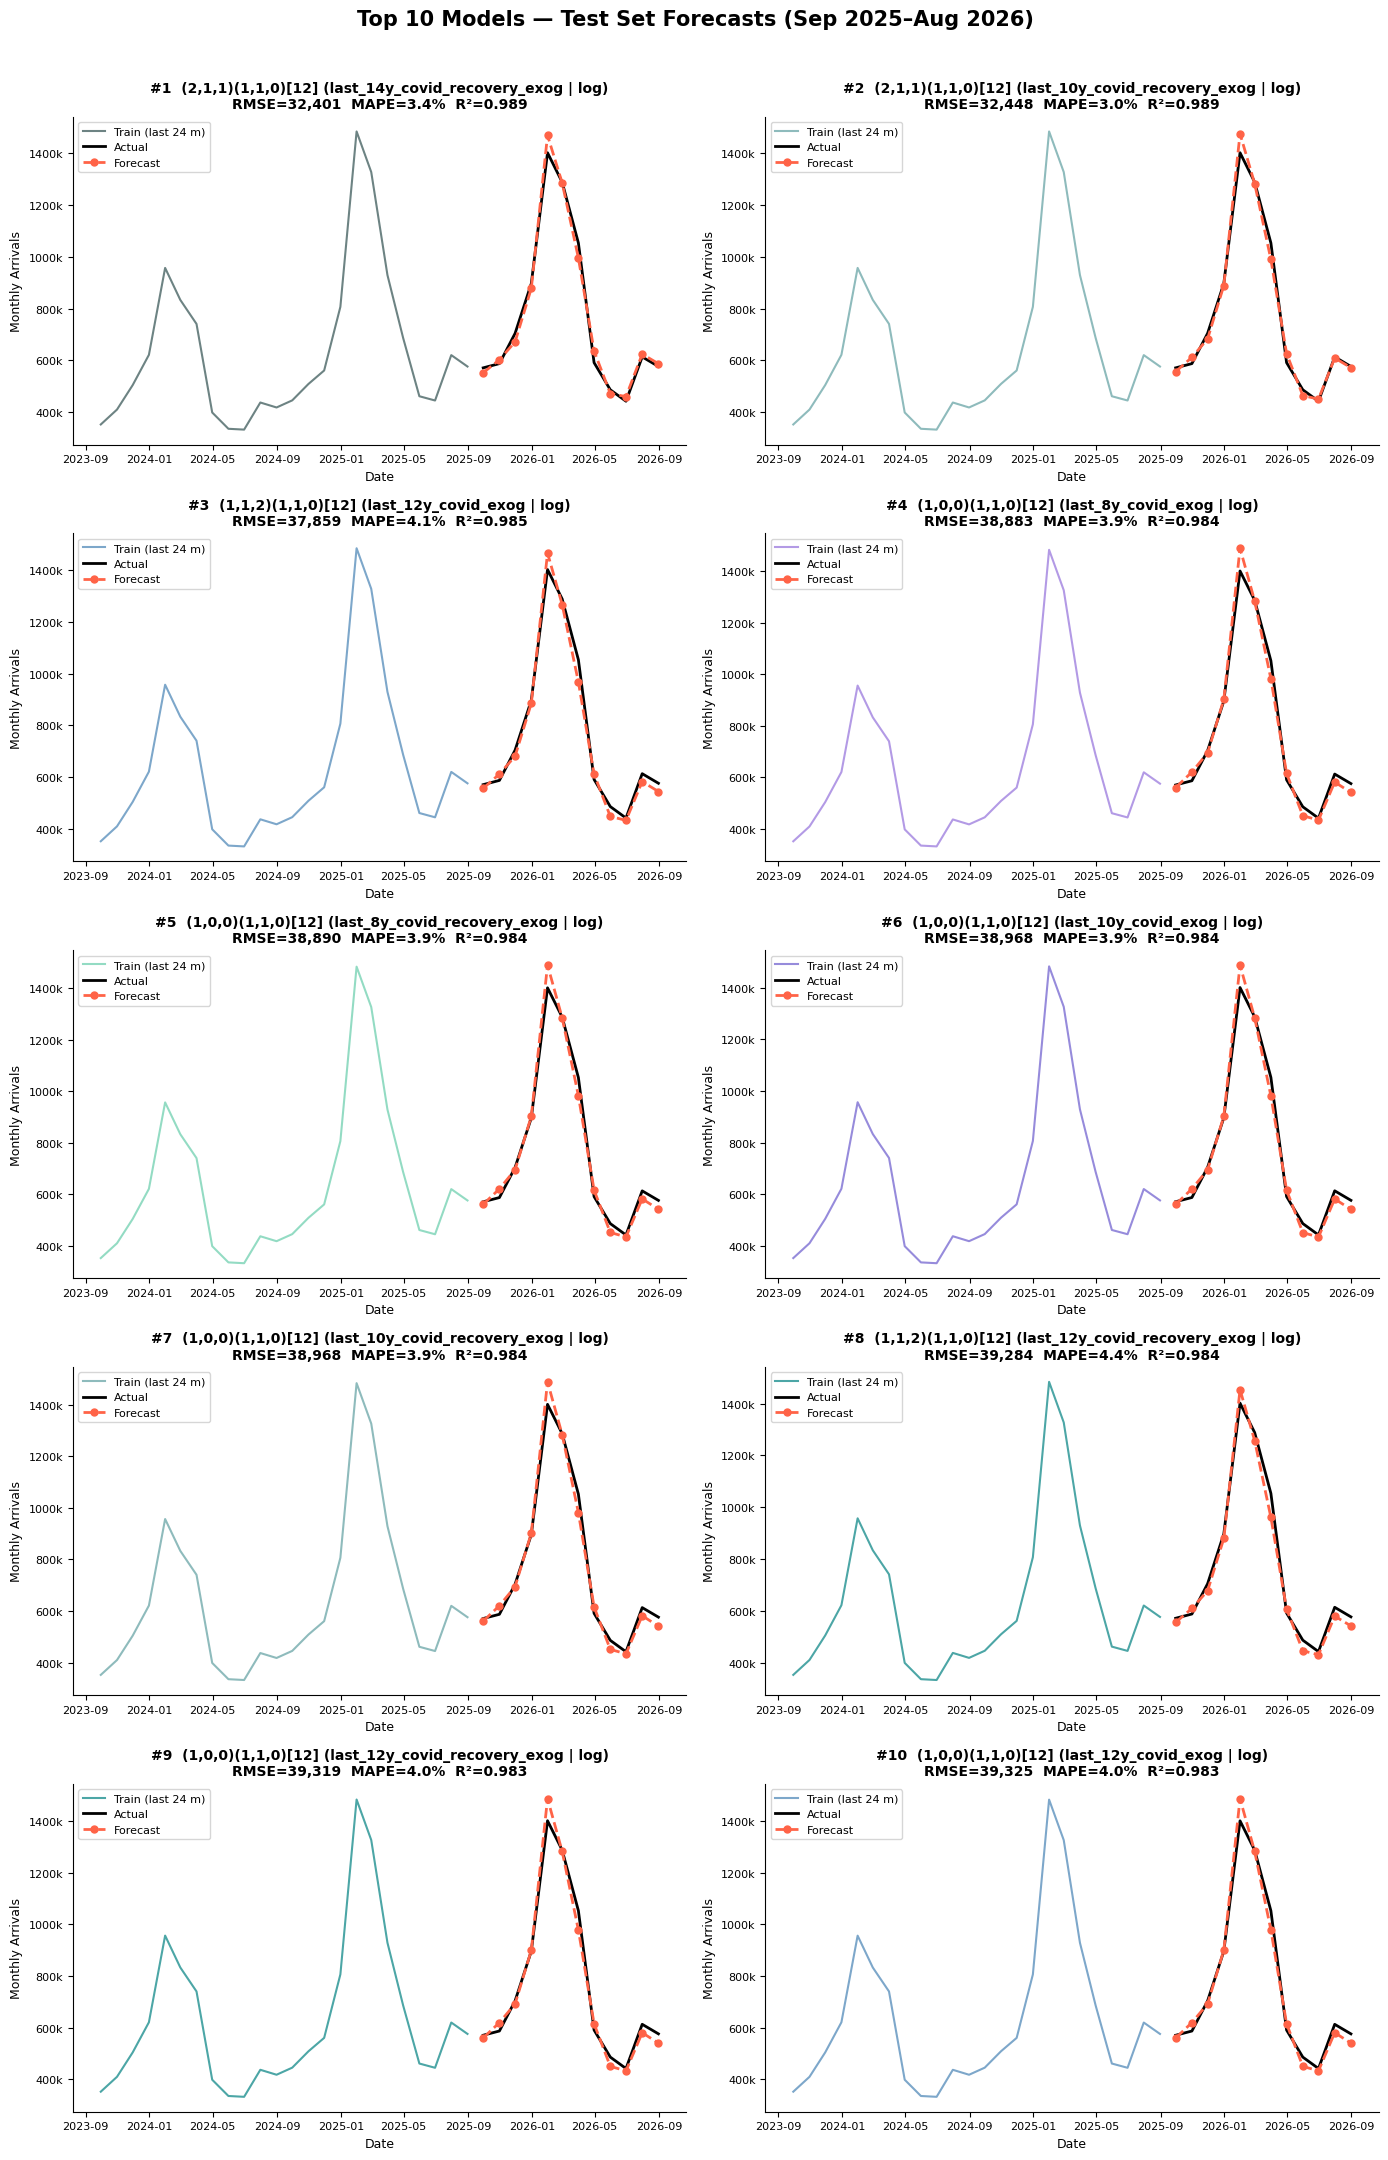

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle(
    f'Top 10 Models — Test Set Forecasts '
    f'({test_monthly.index[0]:%b %Y}–{test_monthly.index[-1]:%b %Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row), fit) in enumerate(zip(axes.flat, top10.iterrows(), top10_fits)):
    cfg = model_configs[(row['data_selection'], row['target_transform'])]
    forecast = forecast_arrivals(fit, cfg)
    train_plot = cfg['raw_series'].iloc[-24:]

    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color=palette[row['data_selection']],
        alpha=0.7,
    )
    ax.plot(
        test_monthly.index,
        test_monthly['arrival_count'],
        label='Actual',
        linewidth=2,
        color='black',
    )
    ax.plot(
        test_monthly.index,
        forecast,
        label='Forecast',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'#{i + 1}  {row["run_name"].replace("SARIMAX", "")}\n'
        f'RMSE={row["rmse"]:,.0f}  MAPE={row["mape"]:.1f}%  R²={row["r2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Monthly Arrivals', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Save the Best Model to MLflow

The best model (rank 1 by test RMSE, across all orders, target transformations and data
selections) is saved to MLflow as a single deployable artifact:

- **What is saved.** An `mlflow.pyfunc` model that wraps the fitted target transformer
  (`none`, `log` or `AutoStationaryTransformer`) together with the fitted SARIMAX results.
  `predict` forecasts on the transformed scale and applies `inverse_transform` internally,
  so the model returns **arrival counts** directly.
- **Self-contained.** The book's `src` package is bundled with `code_paths`, so an
  `auto_stationary` model loads on a machine without the sibling repository. Its
  import-time dependencies (`plotly`, `pymannkendall`) are added to the model's
  requirements.
- **Registry.** The model is registered as `brazil_tourism_sarimax_baseline` and the new
  version gets the alias **`champion`**. Later notebooks (XGBoost, PatchTST) can load the
  baseline with `models:/brazil_tourism_sarimax_baseline@champion`.
- **Input contract.** A DataFrame with a `date` column holding the consecutive month-ends
  right after the end of training (the first test month onwards), plus the exogenous columns the model
  was trained with (if any). The output has the columns `date` and
  `arrival_count_forecast`.

The saved model is reloaded from the registry at the end, and its forecast is checked
against the in-memory model.

In [15]:
from mlflow.models import infer_signature  # noqa: E402

REGISTERED_MODEL_NAME = 'brazil_tourism_sarimax_baseline'
MODEL_ALIAS = 'champion'


class TransformedSARIMAXModel(mlflow.pyfunc.PythonModel):
    """SARIMAX fitted on a transformed target; predicts arrival counts.

    `model_input` must hold the consecutive month-ends right after the end of training
    in a `date` column, plus the exogenous columns used at training time.
    """

    def __init__(self, transformer, sarimax_results, exog_columns):
        self.transformer = transformer
        self.sarimax_results = sarimax_results
        self.exog_columns = exog_columns

    def predict(self, context, model_input, params=None):
        dates = pd.DatetimeIndex(pd.to_datetime(model_input['date']))
        exog = (
            model_input[self.exog_columns].set_index(dates)
            if self.exog_columns
            else None
        )
        transformed = self.sarimax_results.forecast(steps=len(dates), exog=exog)
        forecast = self.transformer.inverse_transform(
            pd.Series(np.asarray(transformed), index=dates)
        )
        return pd.DataFrame({
            'date': dates,
            'arrival_count_forecast': forecast.to_numpy(),
        })


best_row = results_df.iloc[0]
best_cfg = model_configs[(best_row['data_selection'], best_row['target_transform'])]
best_fit = top10_fits[0]
exog_columns = (
    list(best_cfg['exog_train'].columns) if best_cfg['exog_train'] is not None else []
)

python_model = TransformedSARIMAXModel(best_cfg['transformer'], best_fit, exog_columns)
model_input = test_monthly.reset_index()[['date', *exog_columns]]
best_prediction = python_model.predict(None, model_input)
signature = infer_signature(model_input, best_prediction)

print(f'Best model : {best_row["run_name"]}')
print(f'Transform  : {best_cfg["target_transform"]} ({best_cfg["pipeline"]})')
print(
    f'Test RMSE  : {best_row["rmse"]:,.0f}  |  MAPE: {best_row["mape"]:.2f}%  |  '
    f'R²: {best_row["r2"]:.3f}'
)

Best model : SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_recovery_exog | log)
Transform  : log (log)
Test RMSE  : 32,401  |  MAPE: 3.44%  |  R²: 0.989


c:\git_reps\brazil_tourism_forecasting_benchmark\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [16]:
with mlflow.start_run(run_name=f'BEST {best_row["run_name"]}') as best_run:
    p, d_, q = best_row['order']
    P, D_, Q, s_ = best_row['seasonal_order']
    mlflow.log_params({
        'p': p,
        'd': d_,
        'q': q,
        'P': P,
        'D': D_,
        'Q': Q,
        's': s_,
        'transform': best_cfg['target_transform'],
        'ast_pipeline': best_cfg['pipeline'],
        'boxcox_lambda': best_cfg['boxcox_lambda'] or 'none',
        'data_selection': best_row['data_selection'],
        'exog': '+'.join(exog_columns) if exog_columns else 'none',
        'n_train': len(best_cfg['series']),
        'n_test': n_test,
        'selection_metric': 'test_rmse',
    })
    mlflow.log_metrics({
        key: float(best_row[key]) for key in ['rmse', 'mae', 'mape', 'r2', 'aic', 'bic']
    })
    mlflow.set_tags({
        'role': 'baseline',
        'model_family': 'SARIMAX',
        'target_transform': best_cfg['target_transform'],
    })
    model_info = mlflow.pyfunc.log_model(
        name='model',
        python_model=python_model,
        code_paths=[os.path.join(MTSF_REPO_PATH, 'src')],
        signature=signature,
        input_example=model_input,
        registered_model_name=REGISTERED_MODEL_NAME,
        extra_pip_requirements=['plotly', 'pymannkendall'],
    )

mlflow.MlflowClient().set_registered_model_alias(
    REGISTERED_MODEL_NAME, MODEL_ALIAS, model_info.registered_model_version
)

print(f'Run ID            : {best_run.info.run_id}')
print(f'Model URI         : {model_info.model_uri}')
print(
    f'Registered        : {REGISTERED_MODEL_NAME} '
    f'v{model_info.registered_model_version} (@{MODEL_ALIAS})'
)

Registered model 'brazil_tourism_sarimax_baseline' already exists. Creating a new version of this model...
Created version '2' of model 'brazil_tourism_sarimax_baseline'.


Run ID            : a20ea4570037408ba3d8f541af2235e7
Model URI         : models:/m-0401b37389e244d48c06a9f56e4c91ca
Registered        : brazil_tourism_sarimax_baseline v2 (@champion)


In [17]:
loaded_model = mlflow.pyfunc.load_model(
    f'models:/{REGISTERED_MODEL_NAME}@{MODEL_ALIAS}'
)
reloaded_prediction = loaded_model.predict(model_input)

max_abs_diff = np.max(
    np.abs(
        reloaded_prediction['arrival_count_forecast'].to_numpy()
        - best_prediction['arrival_count_forecast'].to_numpy()
    )
)
reloaded_rmse = float(
    np.sqrt(
        np.mean(
            (test_actual - reloaded_prediction['arrival_count_forecast'].to_numpy())
            ** 2
        )
    )
)

print(f'Max |reloaded − in-memory| : {max_abs_diff:.6f}')
print(f'Reloaded test RMSE         : {reloaded_rmse:,.0f}')
reloaded_prediction.assign(actual=test_actual)

Max |reloaded − in-memory| : 0.000000
Reloaded test RMSE         : 32,401


,date,arrival_count_forecast,actual
0,2025-09-30,5.517984e+05,570934.0
1,2025-10-31,6.023787e+05,587312.0
2,2025-11-30,6.712686e+05,704159.0
3,2025-12-31,8.781601e+05,896488.0
4,2026-01-31,1.468389e+06,1401476.0
5,2026-02-28,1.285131e+06,1287800.0
6,2026-03-31,9.953014e+05,1053098.0
7,2026-04-30,6.357915e+05,591049.0
8,2026-05-31,4.718069e+05,486262.0
9,2026-06-30,4.599103e+05,442048.0
